# Analyzing some tendencies after slim dimensionality reduction with Random Embeddings

In this script we just focus on some partial dataset wherein we use $d=20$ on just a subset of functions from BBOB (i.e. $f=\{1,8,11,16,20 \}$). What we want to do is then check how some features from the Exploratory Landscape Analysis Toolbox (i.e. FLACCO) behave under a projection with Random Embeddings with a projection matrix $P \in \mathbb{R}^{d \times q}$. In this case we set $q=10$ as a preliminary value to have $50\%$ reduction.

## Procedure
For this case, we use the package `sklearn.random_projection.GaussianRandomProjection` in order to generate the random projection matrices. This generates random matrices where $\left\|P \right\|_{2}=1.0$. With this in mind, we generate 10 different random projection matrices of this kind. Furthermore, we generated beforehand initial 10 datasets of $\mathbf{X} \in [-5,5]^{d}$ with $100 d$ samples via `LHS`. *A priori*, the sampling scheme wouldn't signify a very different performance with respect to other sampling available techniques since the Random Projection will transform any initial space-filling optimized Design of Experiments scheme into some degenerate one since there'll be artificial correlations caused by the projection into the reduced latent space.

### Sampled ELA Features
After what was discussed in some references (i.e. *Expressiveness and Robustness of Landscape Features*, Renau et al., 2019), we sampled the following sets of ELA Features:
- **Dispersion (disp)**
- **Information Content (ic)**
- **Nearest Best Clustering (nbc)**
- **Principal Component Analysis (pca)**
- **Meta Model (ela_meta)**
- **$y$-distribution (ela_distr)**
- **Level Set (ela_level)**

From the set of features, it's self-evident that the **$y$-distribution** features, these are invariant to any dimensionality reduction techniques since the scope of these features is just the *objective space*. However to account for subsampling in a high dimensional space we proceed to generate subsets of $100 q$ by sampling without replacement from the initial dataset. The idea is then two-fold: 1) We simulate what would happen what happens by keeping the same *dimensionality propertion* and 2) we can study the stability and possible distributions of the features. We hypothesize that the distributions of features by performing this sampling will depend primarily on the sampled function.

In [15]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
# Import necessary libraries
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Load the complete data

complete_data = pd.read_csv('complete_data.csv')

# Display the first few rows of the dataframe
complete_data

,ela_meta.lin_simple.adj_r2,ela_meta.lin_simple.intercept,ela_meta.lin_simple.coef.min,ela_meta.lin_simple.coef.max,ela_meta.lin_simple.coef.max_by_min,ela_meta.lin_w_interact.adj_r2,ela_meta.quad_simple.adj_r2,ela_meta.quad_simple.cond,ela_meta.quad_w_interact.adj_r2,ela_meta.costs_runtime,...,fitness_distance.distance_mean,fitness_distance.distance_std,fitness_distance.fitness_mean,fitness_distance.fitness_std,fitness_distance.costs_runtime,instance_idx,function_idx,n_samples,seed_lhs,dimension
0,0.783415,160.866202,0.304231,6.910379,22.714241,0.776188,1.000000,1.000000,1.000000,3.719,...,14.032960,1.887697,58.859327,21.820572,0.015,0,1,2000,123,20
1,0.790511,335.919412,0.094152,7.892473,83.827071,0.783521,1.000000,1.000000,1.000000,3.422,...,14.351657,1.945978,233.261314,19.001955,0.000,1,1,2000,123,20
2,0.803591,270.793181,0.251632,7.823506,31.091061,0.797038,1.000000,1.000000,1.000000,3.031,...,13.927840,1.859788,164.643075,21.439205,0.000,10,1,2000,123,20
3,0.843960,517.166290,0.219431,7.591202,34.594919,0.838754,1.000000,1.000000,1.000000,2.890,...,14.825050,2.064448,395.044391,25.092178,0.000,11,1,2000,123,20
4,0.806906,687.009508,0.287814,7.854378,27.289751,0.800463,1.000000,1.000000,1.000000,2.953,...,14.271534,1.986882,578.350601,19.216727,0.000,12,1,2000,123,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3595,0.046794,398366.995801,643.524763,6904.351120,10.728959,0.110644,0.479422,1.476567,0.579389,3.282,...,13.669415,1.855700,150043.046968,31099.152534,0.000,5,9,2000,132,20
3596,0.030062,394205.575977,44.395970,5585.930410,125.820664,0.091313,0.470815,1.791405,0.601925,3.969,...,13.611165,1.776596,152344.564933,30025.249845,0.000,6,9,2000,132,20
3597,0.047229,395039.718828,382.408780,8648.555393,22.615996,0.119119,0.477345,1.424640,0.583361,3.547,...,14.367946,2.105526,150410.749166,34466.209774,0.000,7,9,2000,132,20
3598,0.043838,400072.201886,53.282595,8651.571769,162.371442,0.089749,0.469374,2.183223,0.566189,3.671,...,13.671871,1.800489,151853.393155,31118.184509,0.000,8,9,2000,132,20


In [6]:
# Just use functions 1, 8, 11, 16, 20

sets_of_functions = {1, 8, 11, 16, 20}

# Slice the dataframe to only include these functions
filtered_data = complete_data[complete_data['function_idx'].isin(sets_of_functions)]

In [7]:
filtered_data

,ela_meta.lin_simple.adj_r2,ela_meta.lin_simple.intercept,ela_meta.lin_simple.coef.min,ela_meta.lin_simple.coef.max,ela_meta.lin_simple.coef.max_by_min,ela_meta.lin_w_interact.adj_r2,ela_meta.quad_simple.adj_r2,ela_meta.quad_simple.cond,ela_meta.quad_w_interact.adj_r2,ela_meta.costs_runtime,...,fitness_distance.distance_mean,fitness_distance.distance_std,fitness_distance.fitness_mean,fitness_distance.fitness_std,fitness_distance.costs_runtime,instance_idx,function_idx,n_samples,seed_lhs,dimension
0,0.783415,160.866202,0.304231,6.910379,22.714241,0.776188,1.000000,1.000000,1.000000,3.719,...,14.032960,1.887697,58.859327,21.820572,0.015,0,1,2000,123,20
1,0.790511,335.919412,0.094152,7.892473,83.827071,0.783521,1.000000,1.000000,1.000000,3.422,...,14.351657,1.945978,233.261314,19.001955,0.000,1,1,2000,123,20
2,0.803591,270.793181,0.251632,7.823506,31.091061,0.797038,1.000000,1.000000,1.000000,3.031,...,13.927840,1.859788,164.643075,21.439205,0.000,10,1,2000,123,20
3,0.843960,517.166290,0.219431,7.591202,34.594919,0.838754,1.000000,1.000000,1.000000,2.890,...,14.825050,2.064448,395.044391,25.092178,0.000,11,1,2000,123,20
4,0.806906,687.009508,0.287814,7.854378,27.289751,0.800463,1.000000,1.000000,1.000000,2.953,...,14.271534,1.986882,578.350601,19.216727,0.000,12,1,2000,123,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3580,0.628200,626090.727702,2820.782514,28789.761207,10.206303,0.626322,0.911350,21.784536,0.992786,3.421,...,14.902285,2.061293,243184.620023,62112.997946,0.000,5,8,2000,132,20
3581,0.613649,727449.727864,122.111659,41750.535518,341.904580,0.615658,0.916855,60.256643,0.994807,3.453,...,14.915880,2.036828,268221.829937,66315.976419,0.016,6,8,2000,132,20
3582,0.573685,485534.525763,491.100072,25211.699700,51.337194,0.577326,0.898692,59.978242,0.988709,3.453,...,14.279768,1.870411,183649.359532,44820.816548,0.000,7,8,2000,132,20
3583,0.659866,797365.236067,2123.064675,45143.612008,21.263418,0.658571,0.928985,163.693717,0.995746,3.500,...,14.497675,2.059177,300906.196529,69366.401005,0.016,8,8,2000,132,20


In [8]:
# Now load the reduced data
reduced_data = pd.read_csv('reduced_data.csv')

In [9]:
reduced_data

,ela_meta.lin_simple.adj_r2,ela_meta.lin_simple.intercept,ela_meta.lin_simple.coef.min,ela_meta.lin_simple.coef.max,ela_meta.lin_simple.coef.max_by_min,ela_meta.lin_w_interact.adj_r2,ela_meta.quad_simple.adj_r2,ela_meta.quad_simple.cond,ela_meta.quad_w_interact.adj_r2,ela_meta.costs_runtime,...,fitness_distance.fitness_std,fitness_distance.costs_runtime,round,embedding_seed,reduction_ratio,instance_idx,function_idx,n_samples,seed_lhs,dimension
0,0.414429,158.882966,0.266435,6.839539,25.670534,0.417295,0.438440,46.828016,0.475060,0.109,...,19.751069,0.016,0,100,0.5,0,1,2000,123,20
1,0.394250,161.895100,0.024651,6.163927,250.047828,0.418916,0.430783,12.575459,0.472764,0.109,...,23.173220,0.000,1,100,0.5,0,1,2000,123,20
2,0.434782,158.817461,0.397497,6.278454,15.794955,0.449838,0.468053,3.405237,0.486314,0.110,...,24.386751,0.000,10,100,0.5,0,1,2000,123,20
3,0.405718,161.954232,0.269242,6.077695,22.573345,0.415347,0.438340,8.656555,0.474333,0.125,...,19.590598,0.000,11,100,0.5,0,1,2000,123,20
4,0.376893,164.496405,0.164554,5.369180,32.628682,0.391989,0.405033,9.255617,0.440324,0.109,...,19.304881,0.000,12,100,0.5,0,1,2000,123,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247495,0.364117,694194.839351,1196.448239,54489.646765,45.542837,0.418396,0.409691,48.610424,0.494820,0.109,...,76923.610401,0.000,5,110,0.5,9,8,2000,132,20
247496,0.407481,727049.739266,83.368846,60548.345229,726.270639,0.445299,0.433860,21.416934,0.497396,0.109,...,80171.113539,0.000,6,110,0.5,9,8,2000,132,20
247497,0.428751,699210.866270,1245.238158,57520.488291,46.192359,0.460425,0.449992,19.177634,0.551407,0.141,...,58285.072858,0.000,7,110,0.5,9,8,2000,132,20
247498,0.382842,705071.356248,1623.988068,55404.897918,34.116567,0.417184,0.409047,20.189778,0.467551,0.125,...,80529.647982,0.000,8,110,0.5,9,8,2000,132,20


Now that the reduced data is loaded, we proceed with the analysis and plotting as needed. Now we proceed to remove `runtime` features from both datasets.

In [12]:
# Remove columns where names contain `runtime`

cols_to_remove = [col for col in reduced_data.columns if 'runtime' in col]

reduced_data_cleaned = reduced_data.drop(columns=cols_to_remove)

reduced_data_cleaned

,ela_meta.lin_simple.adj_r2,ela_meta.lin_simple.intercept,ela_meta.lin_simple.coef.min,ela_meta.lin_simple.coef.max,ela_meta.lin_simple.coef.max_by_min,ela_meta.lin_w_interact.adj_r2,ela_meta.quad_simple.adj_r2,ela_meta.quad_simple.cond,ela_meta.quad_w_interact.adj_r2,ela_distr.skewness,...,fitness_distance.fitness_mean,fitness_distance.fitness_std,round,embedding_seed,reduction_ratio,instance_idx,function_idx,n_samples,seed_lhs,dimension
0,0.414429,158.882966,0.266435,6.839539,25.670534,0.417295,0.438440,46.828016,0.475060,0.292291,...,60.571687,19.751069,0,100,0.5,0,1,2000,123,20
1,0.394250,161.895100,0.024651,6.163927,250.047828,0.418916,0.430783,12.575459,0.472764,0.185883,...,61.852641,23.173220,1,100,0.5,0,1,2000,123,20
2,0.434782,158.817461,0.397497,6.278454,15.794955,0.449838,0.468053,3.405237,0.486314,0.095578,...,49.480108,24.386751,10,100,0.5,0,1,2000,123,20
3,0.405718,161.954232,0.269242,6.077695,22.573345,0.415347,0.438340,8.656555,0.474333,0.226328,...,62.295538,19.590598,11,100,0.5,0,1,2000,123,20
4,0.376893,164.496405,0.164554,5.369180,32.628682,0.391989,0.405033,9.255617,0.440324,0.168636,...,61.593925,19.304881,12,100,0.5,0,1,2000,123,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247495,0.364117,694194.839351,1196.448239,54489.646765,45.542837,0.418396,0.409691,48.610424,0.494820,0.418354,...,254603.885272,76923.610401,5,110,0.5,9,8,2000,132,20
247496,0.407481,727049.739266,83.368846,60548.345229,726.270639,0.445299,0.433860,21.416934,0.497396,0.612227,...,272771.705669,80171.113539,6,110,0.5,9,8,2000,132,20
247497,0.428751,699210.866270,1245.238158,57520.488291,46.192359,0.460425,0.449992,19.177634,0.551407,0.577808,...,252887.054760,58285.072858,7,110,0.5,9,8,2000,132,20
247498,0.382842,705071.356248,1623.988068,55404.897918,34.116567,0.417184,0.409047,20.189778,0.467551,0.551090,...,268838.030147,80529.647982,8,110,0.5,9,8,2000,132,20


In [13]:
cols_to_remove = [col for col in complete_data.columns if 'runtime' in col]

complete_data_cleaned = complete_data.drop(columns=cols_to_remove)

complete_data_cleaned

,ela_meta.lin_simple.adj_r2,ela_meta.lin_simple.intercept,ela_meta.lin_simple.coef.min,ela_meta.lin_simple.coef.max,ela_meta.lin_simple.coef.max_by_min,ela_meta.lin_w_interact.adj_r2,ela_meta.quad_simple.adj_r2,ela_meta.quad_simple.cond,ela_meta.quad_w_interact.adj_r2,ela_distr.skewness,...,fitness_distance.fd_cov,fitness_distance.distance_mean,fitness_distance.distance_std,fitness_distance.fitness_mean,fitness_distance.fitness_std,instance_idx,function_idx,n_samples,seed_lhs,dimension
0,0.783415,160.866202,0.304231,6.910379,22.714241,0.776188,1.000000,1.000000,1.000000,0.173636,...,21.526406,14.032960,1.887697,58.859327,21.820572,0,1,2000,123,20
1,0.790511,335.919412,0.094152,7.892473,83.827071,0.783521,1.000000,1.000000,1.000000,0.194581,...,19.950997,14.351657,1.945978,233.261314,19.001955,1,1,2000,123,20
2,0.803591,270.793181,0.251632,7.823506,31.091061,0.797038,1.000000,1.000000,1.000000,0.180206,...,15.432277,13.927840,1.859788,164.643075,21.439205,10,1,2000,123,20
3,0.843960,517.166290,0.219431,7.591202,34.594919,0.838754,1.000000,1.000000,1.000000,0.141247,...,24.150423,14.825050,2.064448,395.044391,25.092178,11,1,2000,123,20
4,0.806906,687.009508,0.287814,7.854378,27.289751,0.800463,1.000000,1.000000,1.000000,0.180001,...,12.882505,14.271534,1.986882,578.350601,19.216727,12,1,2000,123,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3595,0.046794,398366.995801,643.524763,6904.351120,10.728959,0.110644,0.479422,1.476567,0.579389,1.619896,...,12726.435816,13.669415,1.855700,150043.046968,31099.152534,5,9,2000,132,20
3596,0.030062,394205.575977,44.395970,5585.930410,125.820664,0.091313,0.470815,1.791405,0.601925,1.432166,...,16061.680279,13.611165,1.776596,152344.564933,30025.249845,6,9,2000,132,20
3597,0.047229,395039.718828,382.408780,8648.555393,22.615996,0.119119,0.477345,1.424640,0.583361,1.360810,...,27272.481155,14.367946,2.105526,150410.749166,34466.209774,7,9,2000,132,20
3598,0.043838,400072.201886,53.282595,8651.571769,162.371442,0.089749,0.469374,2.183223,0.566189,1.641267,...,13744.893898,13.671871,1.800489,151853.393155,31118.184509,8,9,2000,132,20


In [14]:
# These are the prefixes of the feature sets
feature_set_prefixes = (
    'ela_level',
    'ela_meta',
    'ela_distr',
    'nbc',
    'pca',
    'ic',
    'disp',
    'fitness_distance'
)

In [28]:
def plot_feature_contrast_per_fid_instance_original_database(
    original_database: pd.DataFrame,
    reduced_database: pd.DataFrame,
    feature_name: str,
    n_samples: int = 2000,
    dataset_seed: int = 123,
    fid: int = 1,
    instance: int = 0,
    dimension: int = 20,
):
    # Filter original database (single realization)
    original_filtered = original_database[
        (original_database["function_idx"] == fid)
        & (original_database["instance_idx"] == instance)
        & (original_database["dimension"] == dimension)
        & (original_database["n_samples"] == n_samples)
        & (original_database["seed_lhs"] == dataset_seed)
    ]

    # Filter reduced database (distribution over embedding_seed)
    reduced_filtered = reduced_database[
        (reduced_database["function_idx"] == fid)
        & (reduced_database["instance_idx"] == instance)
        & (reduced_database["dimension"] == dimension)
        & (reduced_database["n_samples"] == n_samples)
        & (reduced_database["seed_lhs"] == dataset_seed)
    ]

    # Extract feature(s)
    original_feature = original_filtered.loc[
        :, original_filtered.columns.str.contains(feature_name)
    ]

    reduced_feature = reduced_filtered.loc[
        :, reduced_filtered.columns.str.contains(feature_name)
    ]

    if original_feature.shape[0] != 1:
        raise ValueError("Original feature must contain exactly one row.")

    # --- Long-format reduced data with embedding seed ---
    reduced_long = reduced_filtered[["embedding_seed"]].join(reduced_feature)
    reduced_long = reduced_long.melt(
        id_vars="embedding_seed",
        var_name="feature",
        value_name="value",
    )

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(14, 6))

    sns.violinplot(
        data=reduced_long,
        x="embedding_seed",
        y="value",
        inner="quartile",
        cut=0,
        density_norm='width',
        ax=ax,
        color="lightblue",
    )

    # --- Reference line from original feature ---
    for col in original_feature.columns:
        ax.axhline(
            original_feature.iloc[0][col],
            color="darkgreen",
            linestyle="--",
            linewidth=2,
            label="Full Dimensional Feature Value",
        )

    ax.set_title(
        f"{feature_name} | fid={fid}, instance={instance}, dim={dimension}, seed_lhs={dataset_seed}, n_samples={n_samples}"
    )
    ax.set_xlabel("Projection Identifier (embedding seed)")
    ax.set_ylabel(feature_name)

    # Avoid duplicate legend entries
    handles, labels = ax.get_legend_handles_labels()
    if labels:
        ax.legend(handles[:1], labels[:1])

    plt.show()

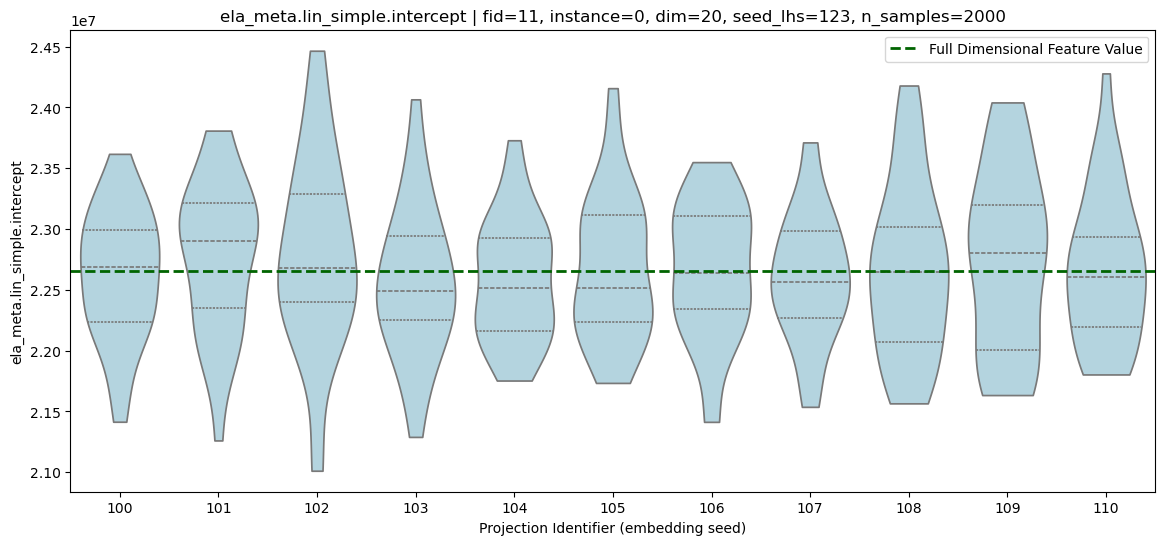

In [34]:
# plot_feature_contrast_per_fid_instance_original_database(

plot_feature_contrast_per_fid_instance_original_database(original_database=complete_data_cleaned,
                                                        reduced_database=reduced_data_cleaned,
                                                        feature_name='ela_meta.lin_simple.intercept',
                                                        fid=11,
                                                        instance=0)

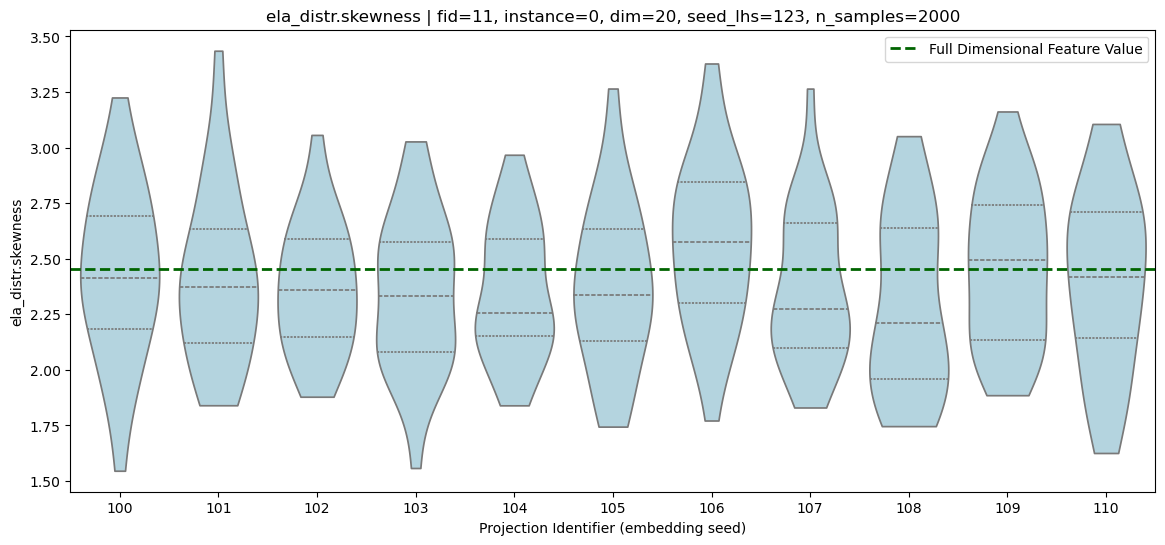

In [71]:
# plot_feature_contrast_per_fid_instance_original_database(

plot_feature_contrast_per_fid_instance_original_database(original_database=complete_data_cleaned,
                                                        reduced_database=reduced_data_cleaned,
                                                        feature_name='ela_distr.skewness',
                                                        fid=11,
                                                        instance=0)

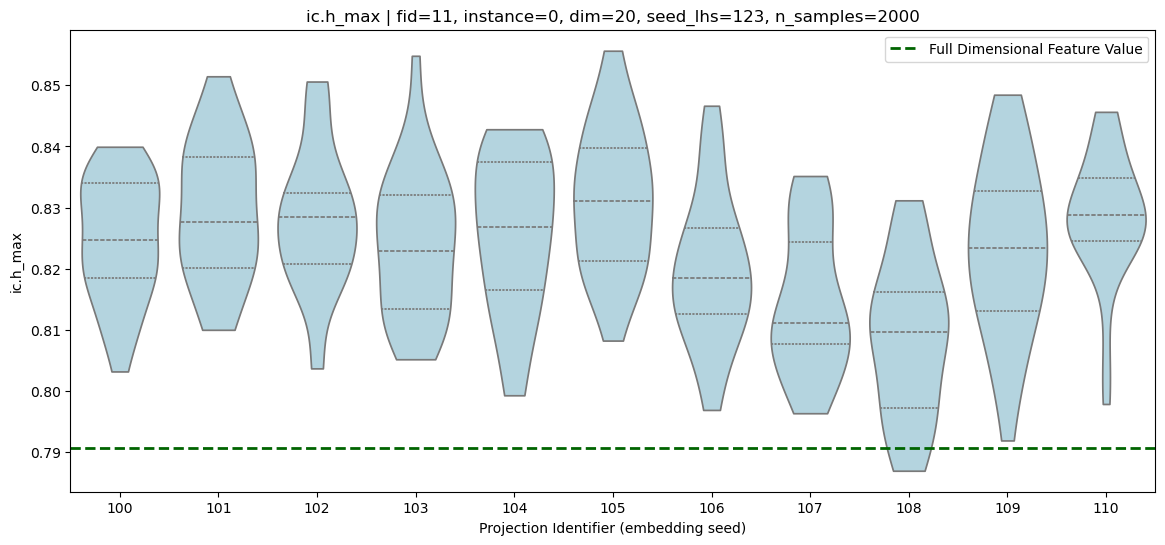

In [ ]:
plot_feature_contrast_per_fid_instance_original_database(original_database=complete_data_cleaned,
                                                        reduced_database=reduced_data_cleaned,
                                                        feature_name='ic.h_max',
                                                        fid=8,
                                                        instance=0)

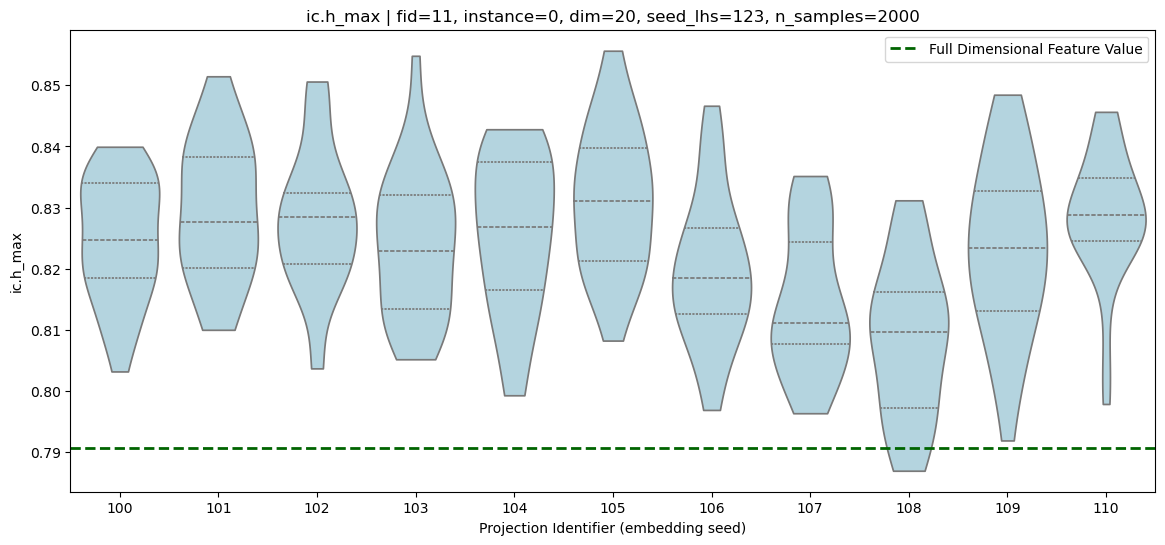

In [90]:
plot_feature_contrast_per_fid_instance_original_database(original_database=complete_data_cleaned,
                                                        reduced_database=reduced_data_cleaned,
                                                        feature_name='ic.h_max',
                                                        fid=11,
                                                        instance=0)

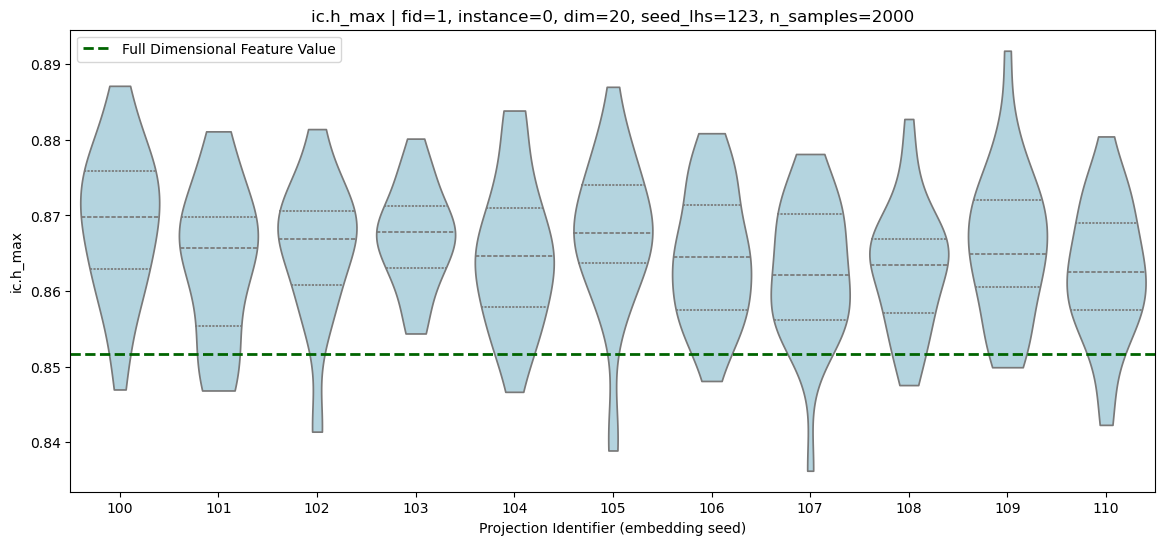

In [42]:
plot_feature_contrast_per_fid_instance_original_database(original_database=complete_data_cleaned,
                                                        reduced_database=reduced_data_cleaned,
                                                        feature_name='ic.h_max',
                                                        fid=1,
                                                        instance=0)

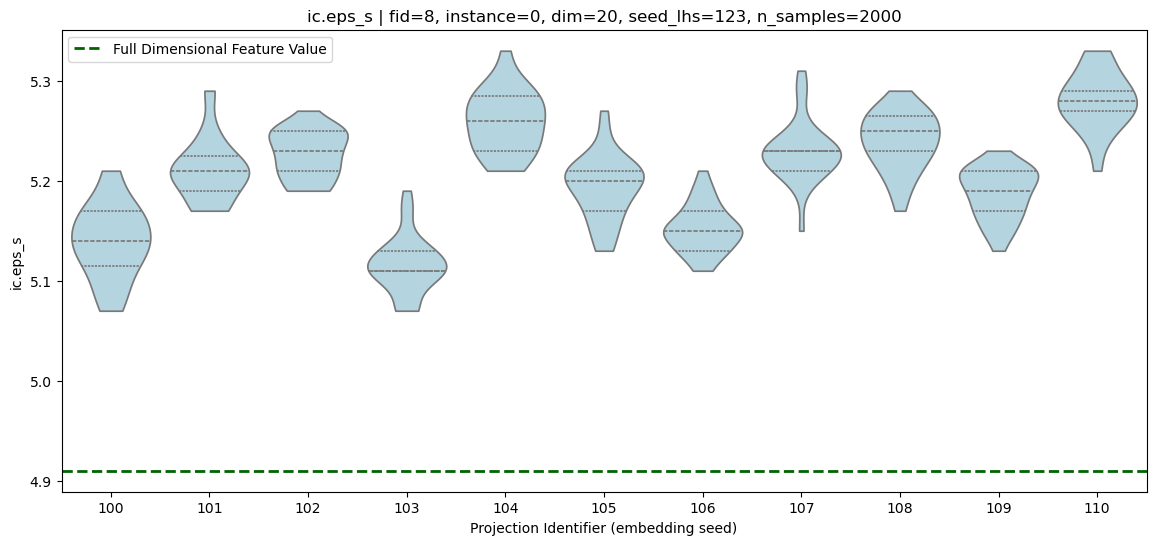

In [76]:
plot_feature_contrast_per_fid_instance_original_database(original_database=complete_data_cleaned,
                                                        reduced_database=reduced_data_cleaned,
                                                        feature_name='ic.eps_s',
                                                        fid=8,
                                                        instance=0)

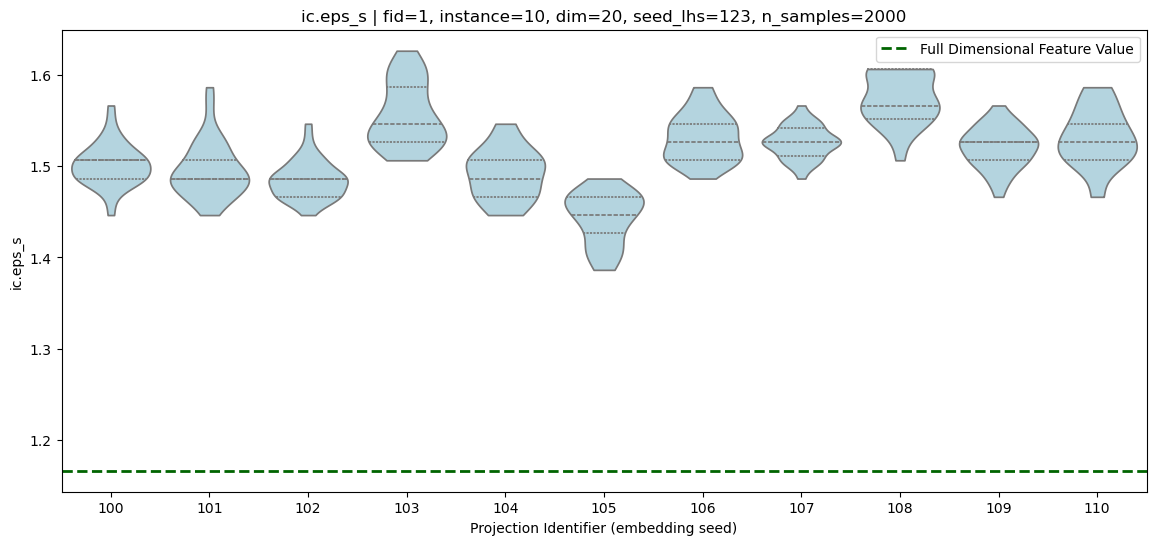

In [86]:
plot_feature_contrast_per_fid_instance_original_database(original_database=complete_data_cleaned,
                                                        reduced_database=reduced_data_cleaned,
                                                        feature_name='ic.eps_s',
                                                        fid=1,
                                                        instance=10)

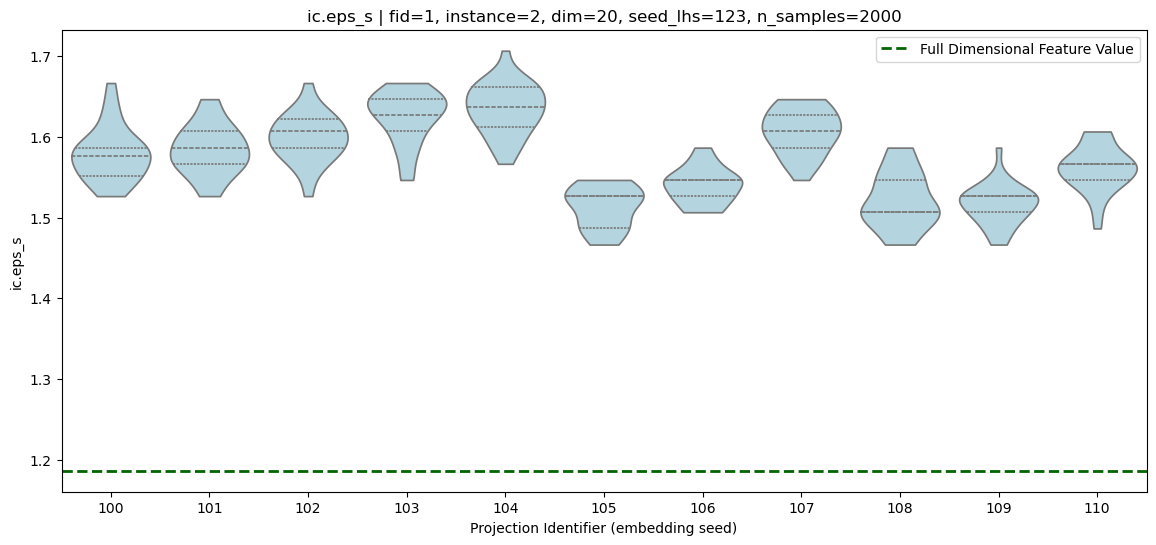

In [89]:
plot_feature_contrast_per_fid_instance_original_database(original_database=complete_data_cleaned,
                                                        reduced_database=reduced_data_cleaned,
                                                        feature_name='ic.eps_s',
                                                        fid=1,
                                                        instance=2,
                                                        dataset_seed=123)

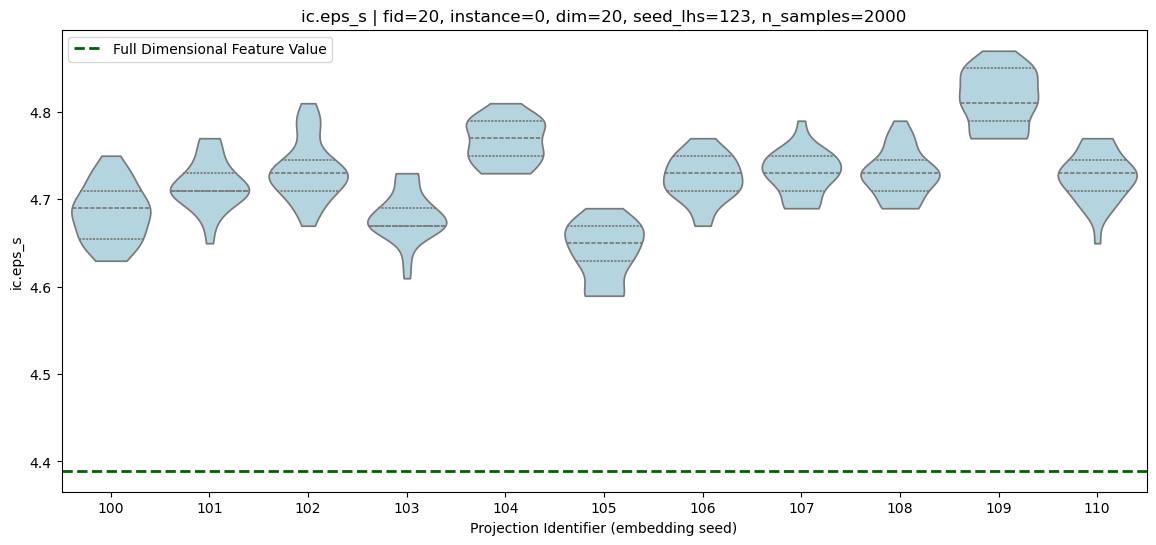

In [38]:
plot_feature_contrast_per_fid_instance_original_database(original_database=complete_data_cleaned,
                                                        reduced_database=reduced_data_cleaned,
                                                        feature_name='ic.eps_s',
                                                        fid=20,
                                                        instance=0)

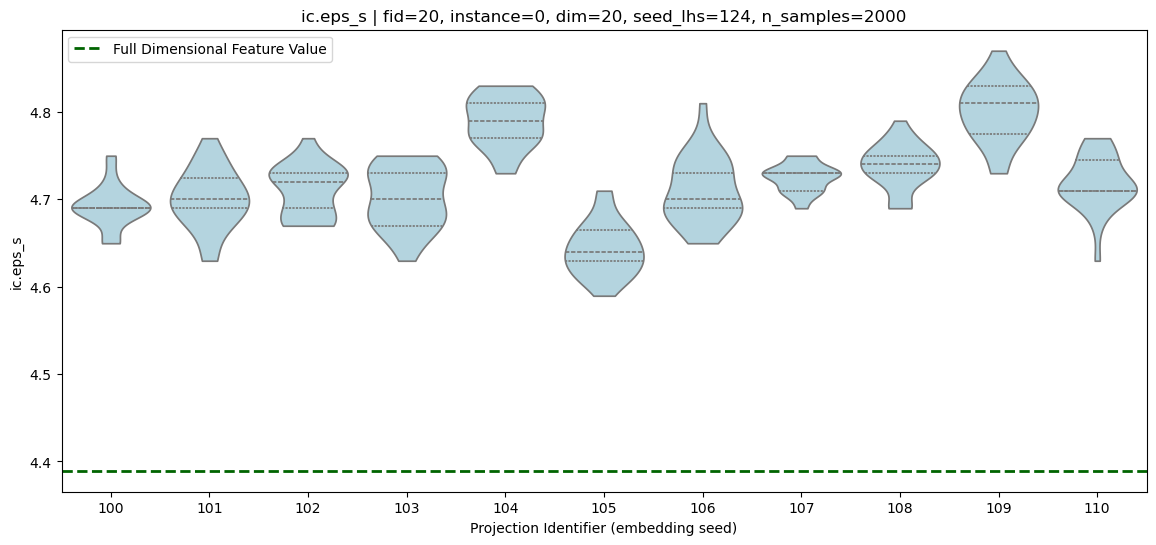

In [56]:
plot_feature_contrast_per_fid_instance_original_database(original_database=complete_data_cleaned,
                                                        reduced_database=reduced_data_cleaned,
                                                        feature_name='ic.eps_s',
                                                        dataset_seed=124,
                                                        fid=20,
                                                        instance=0)

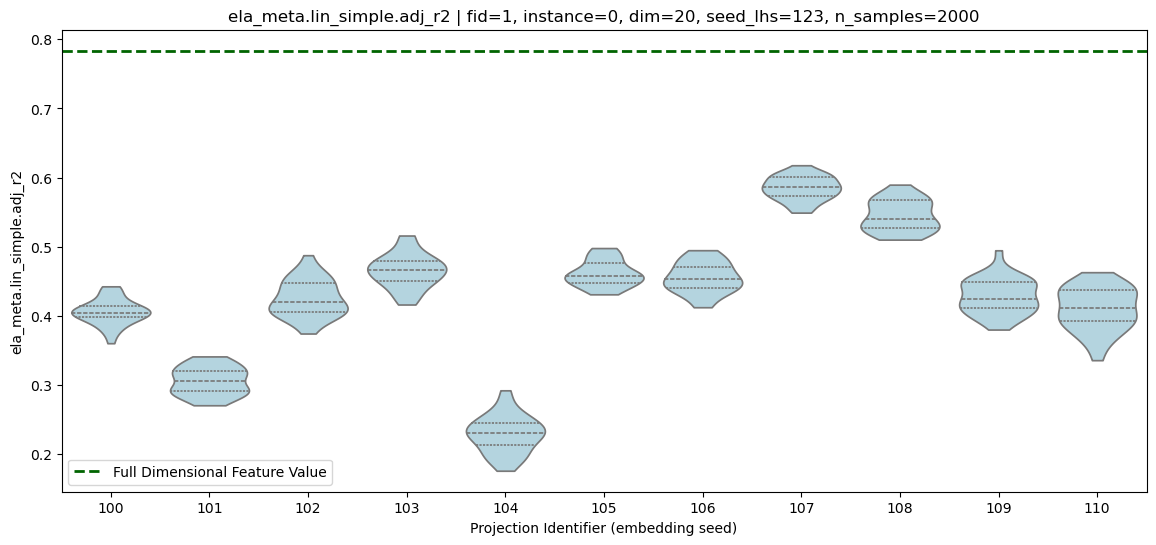

In [54]:
plot_feature_contrast_per_fid_instance_original_database(original_database=complete_data_cleaned,
                                                        reduced_database=reduced_data_cleaned,
                                                        feature_name='ela_meta.lin_simple.adj_r2',
                                                        fid=1,
                                                        instance=0,
                                                        dataset_seed=123)

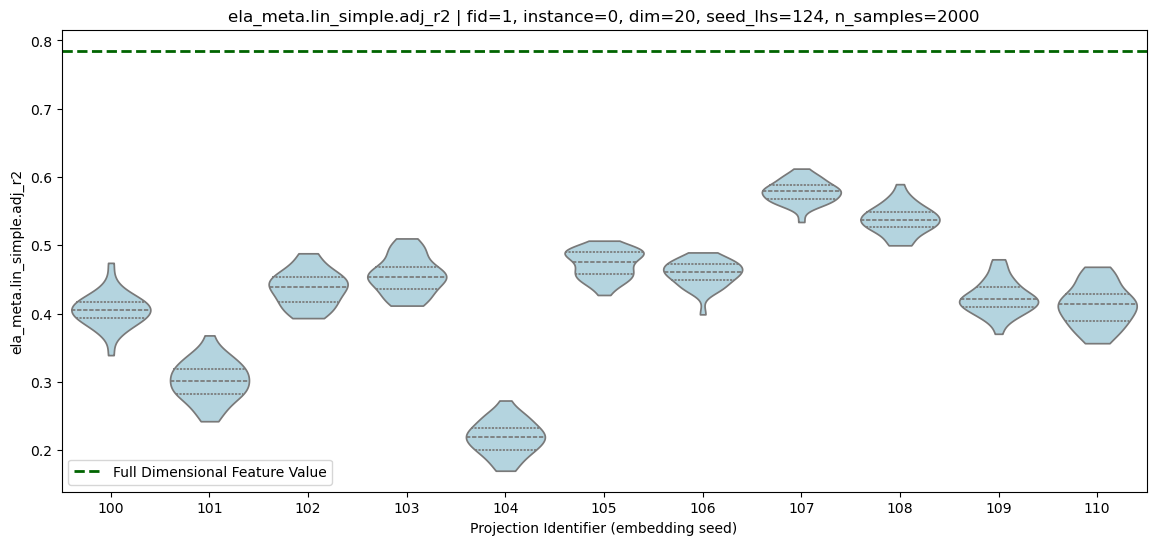

In [55]:
plot_feature_contrast_per_fid_instance_original_database(original_database=complete_data_cleaned,
                                                        reduced_database=reduced_data_cleaned,
                                                        feature_name='ela_meta.lin_simple.adj_r2',
                                                        fid=1,
                                                        dataset_seed=124)

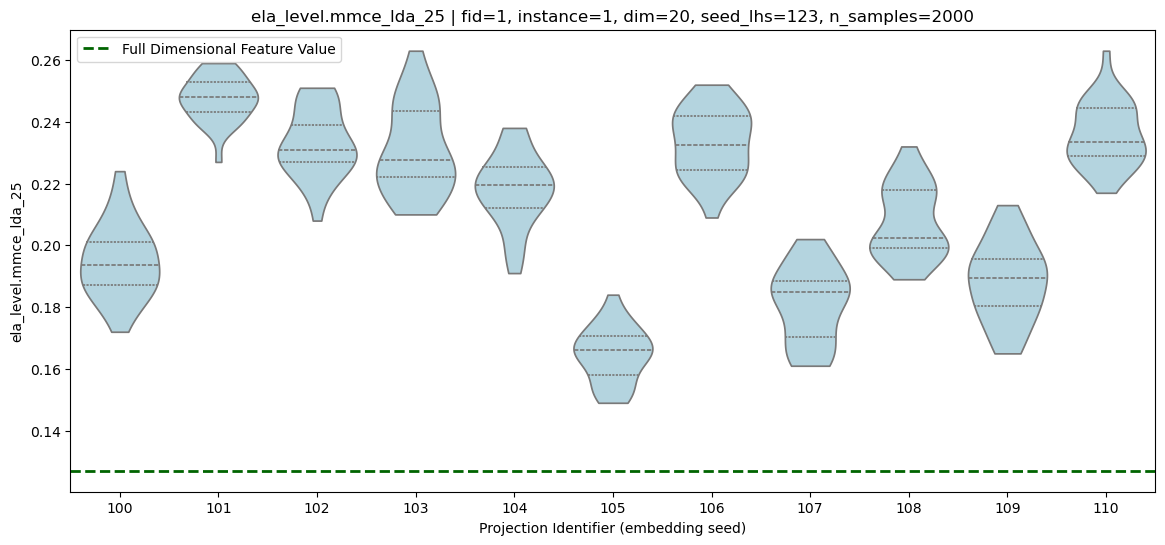

In [44]:
plot_feature_contrast_per_fid_instance_original_database(original_database=complete_data_cleaned,
                                                        reduced_database=reduced_data_cleaned,
                                                        feature_name='ela_level.mmce_lda_25',
                                                        fid=1,
                                                        instance=1)

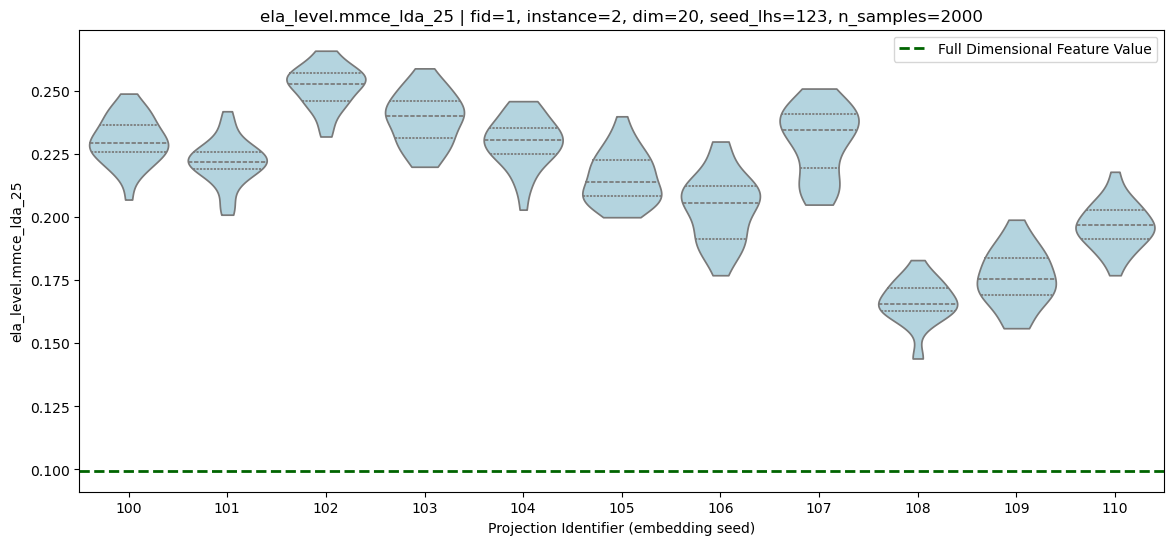

In [45]:
plot_feature_contrast_per_fid_instance_original_database(original_database=complete_data_cleaned,
                                                        reduced_database=reduced_data_cleaned,
                                                        feature_name='ela_level.mmce_lda_25',
                                                        fid=1,
                                                        instance=2)

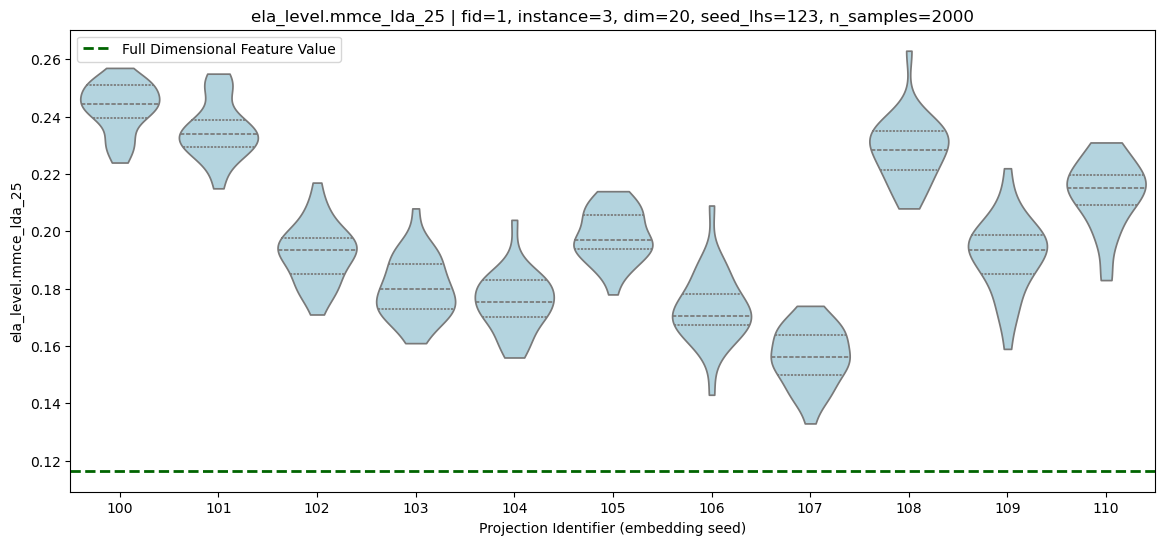

In [46]:
plot_feature_contrast_per_fid_instance_original_database(original_database=complete_data_cleaned,
                                                        reduced_database=reduced_data_cleaned,
                                                        feature_name='ela_level.mmce_lda_25',
                                                        fid=1,
                                                        instance=3)

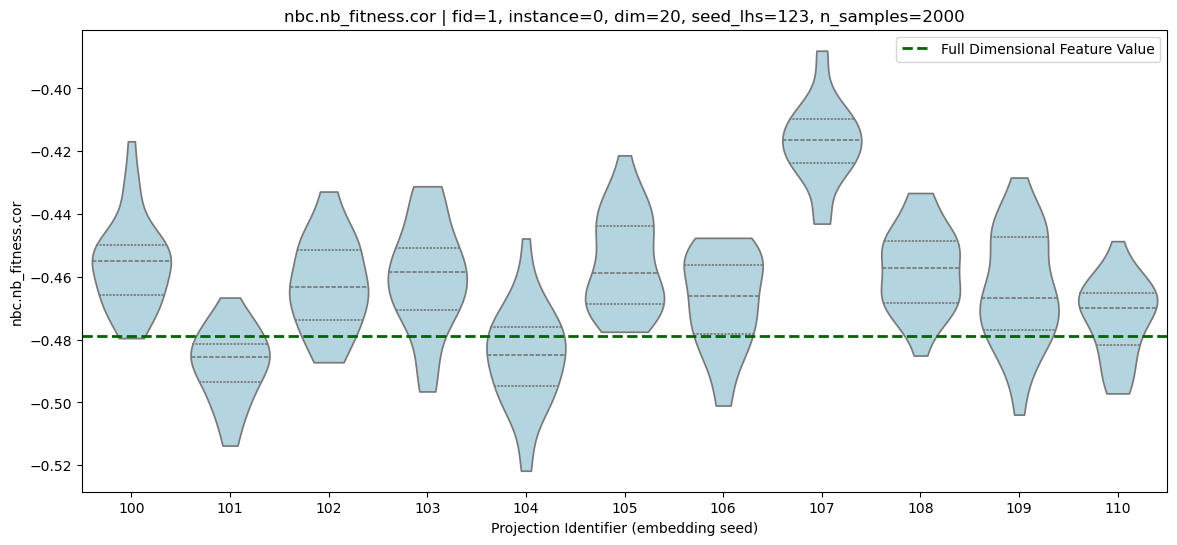

In [50]:
plot_feature_contrast_per_fid_instance_original_database(original_database=complete_data_cleaned,
                                                        reduced_database=reduced_data_cleaned,
                                                        feature_name='nbc.nb_fitness.cor',
                                                        fid=1,
                                                        instance=0)

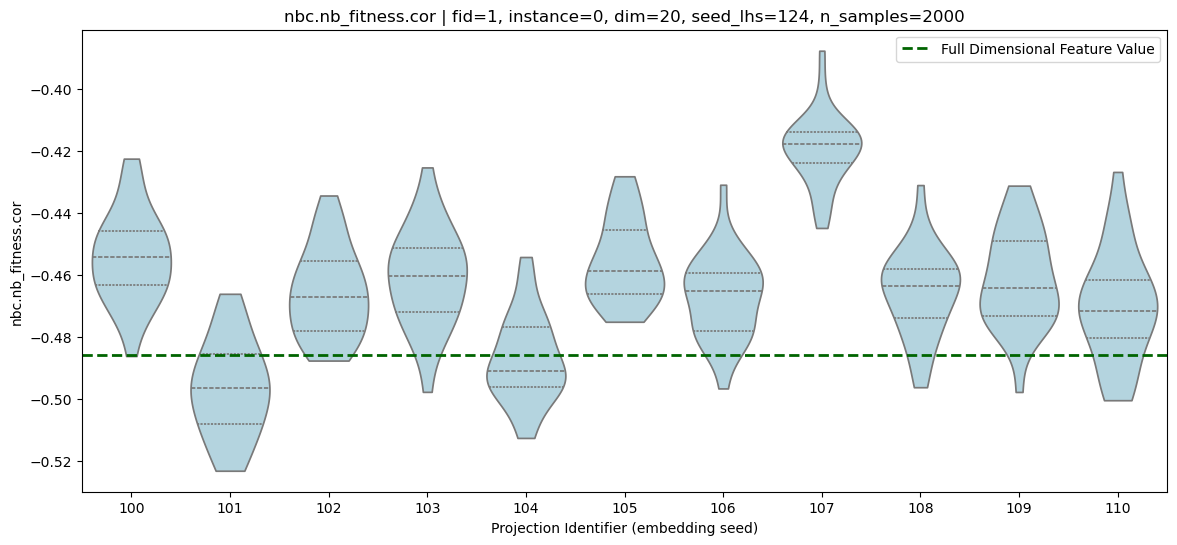

In [51]:
plot_feature_contrast_per_fid_instance_original_database(original_database=complete_data_cleaned,
                                                        reduced_database=reduced_data_cleaned,
                                                        feature_name='nbc.nb_fitness.cor',
                                                        fid=1,
                                                        dataset_seed=124,
                                                        instance=0)

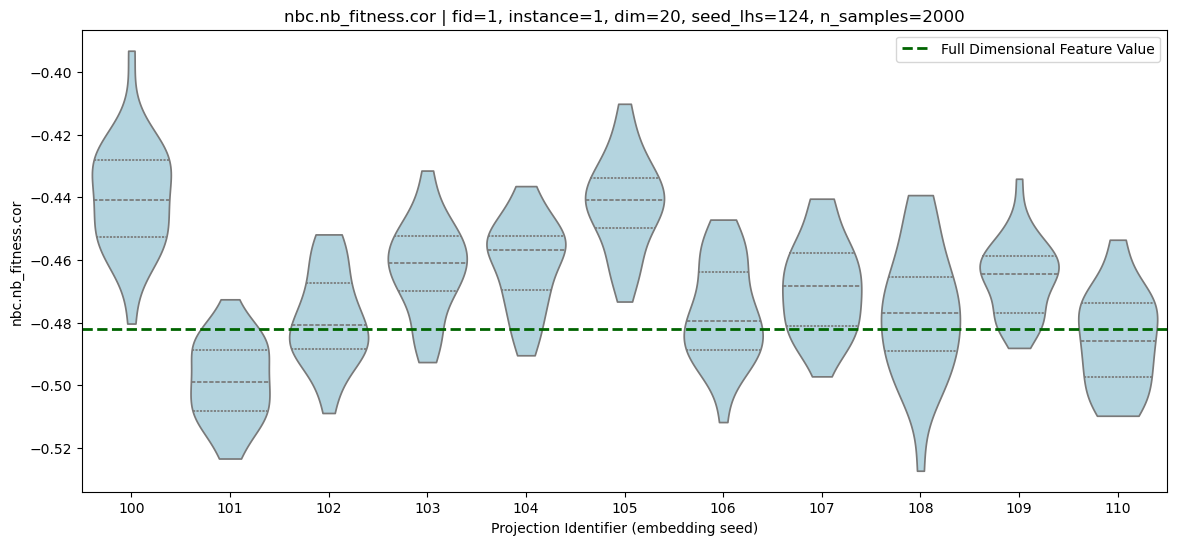

In [70]:
plot_feature_contrast_per_fid_instance_original_database(original_database=complete_data_cleaned,
                                                        reduced_database=reduced_data_cleaned,
                                                        feature_name='nbc.nb_fitness.cor',
                                                        fid=1,
                                                        dataset_seed=124,
                                                        instance=1)

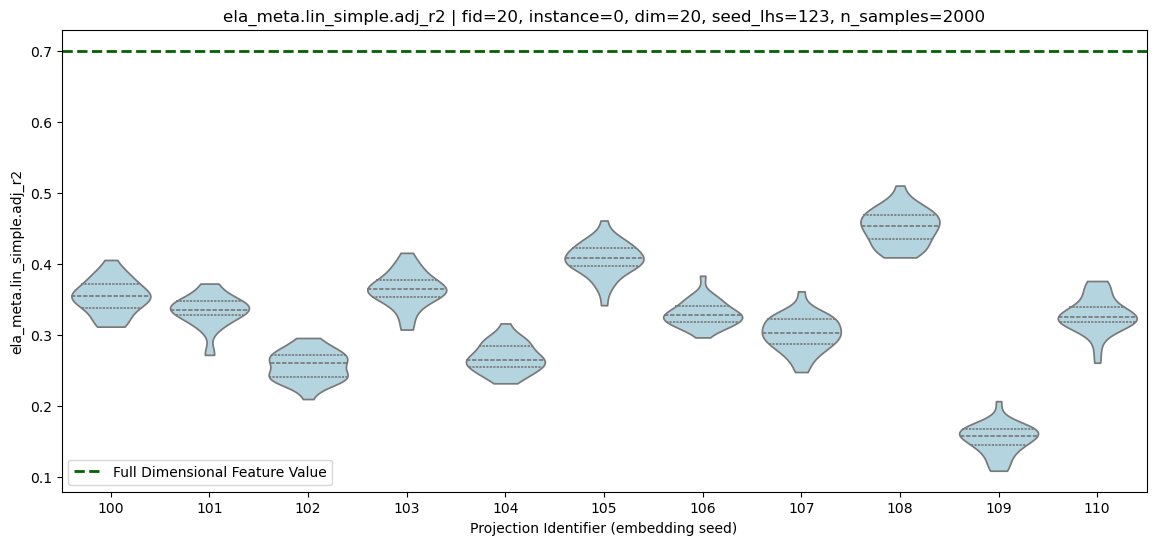

In [59]:
plot_feature_contrast_per_fid_instance_original_database(original_database=complete_data_cleaned,
                                                        reduced_database=reduced_data_cleaned,
                                                        feature_name='ela_meta.lin_simple.adj_r2',
                                                        fid=20,
                                                        dataset_seed=123,
                                                        instance=0)

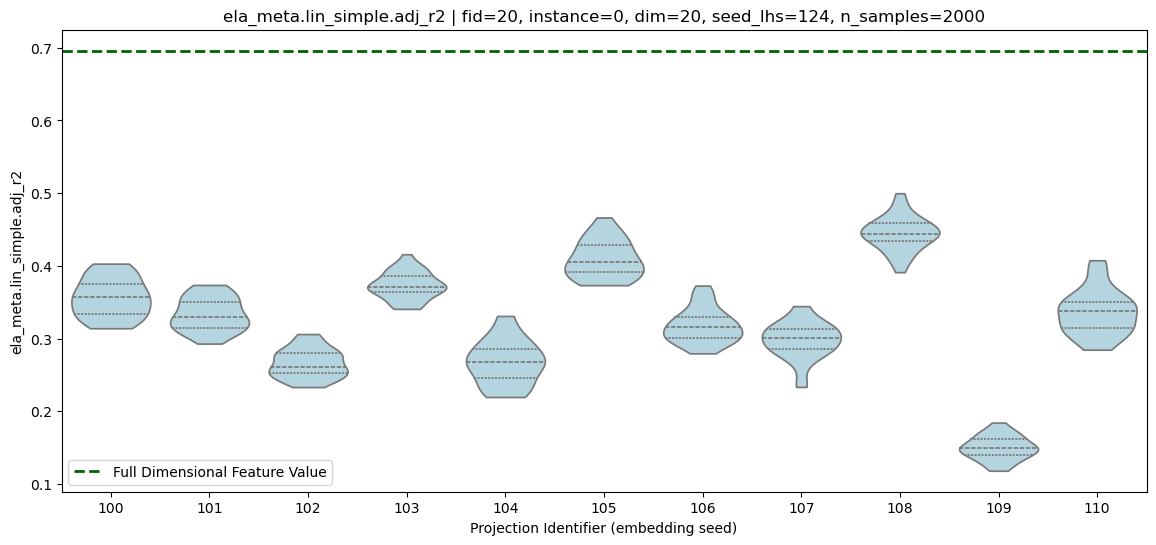

In [60]:
plot_feature_contrast_per_fid_instance_original_database(original_database=complete_data_cleaned,
                                                        reduced_database=reduced_data_cleaned,
                                                        feature_name='ela_meta.lin_simple.adj_r2',
                                                        fid=20,
                                                        dataset_seed=124,
                                                        instance=0)

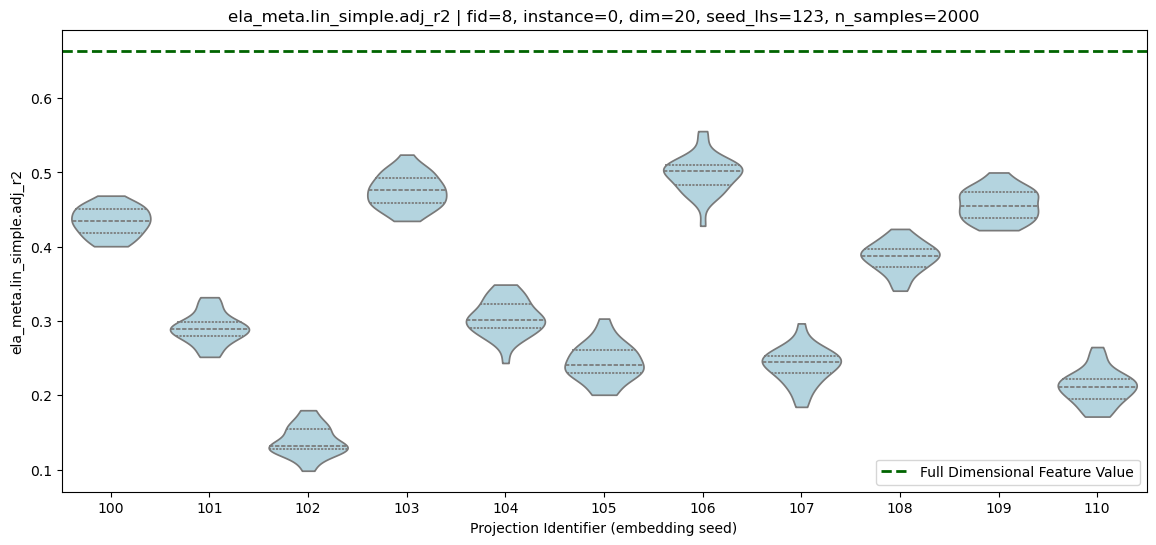

In [61]:
plot_feature_contrast_per_fid_instance_original_database(original_database=complete_data_cleaned,
                                                        reduced_database=reduced_data_cleaned,
                                                        feature_name='ela_meta.lin_simple.adj_r2',
                                                        fid=8,
                                                        dataset_seed=123,
                                                        instance=0)

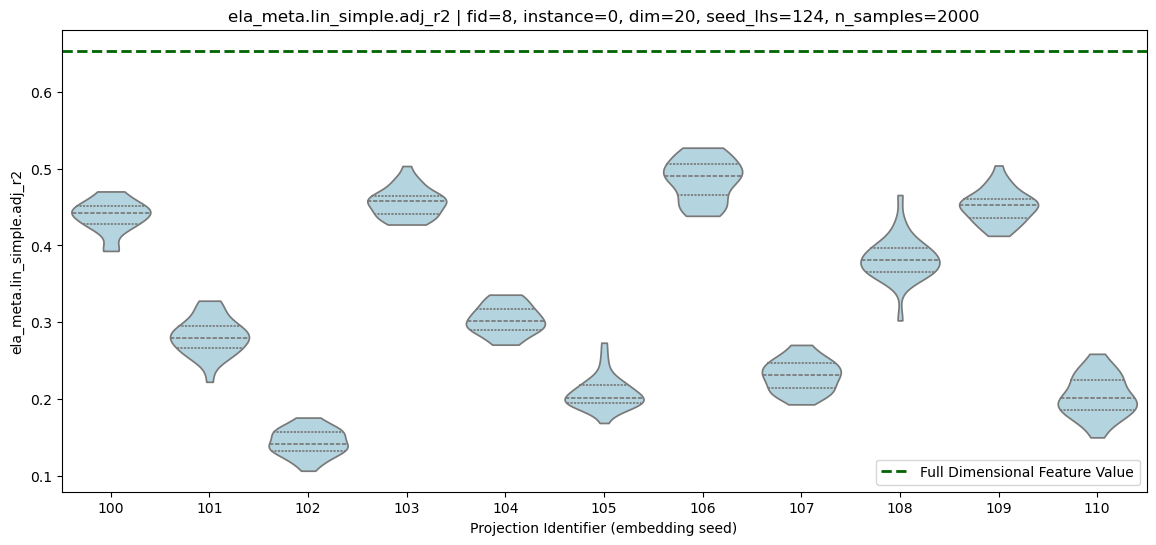

In [62]:
plot_feature_contrast_per_fid_instance_original_database(original_database=complete_data_cleaned,
                                                        reduced_database=reduced_data_cleaned,
                                                        feature_name='ela_meta.lin_simple.adj_r2',
                                                        fid=8,
                                                        dataset_seed=124,
                                                        instance=0)

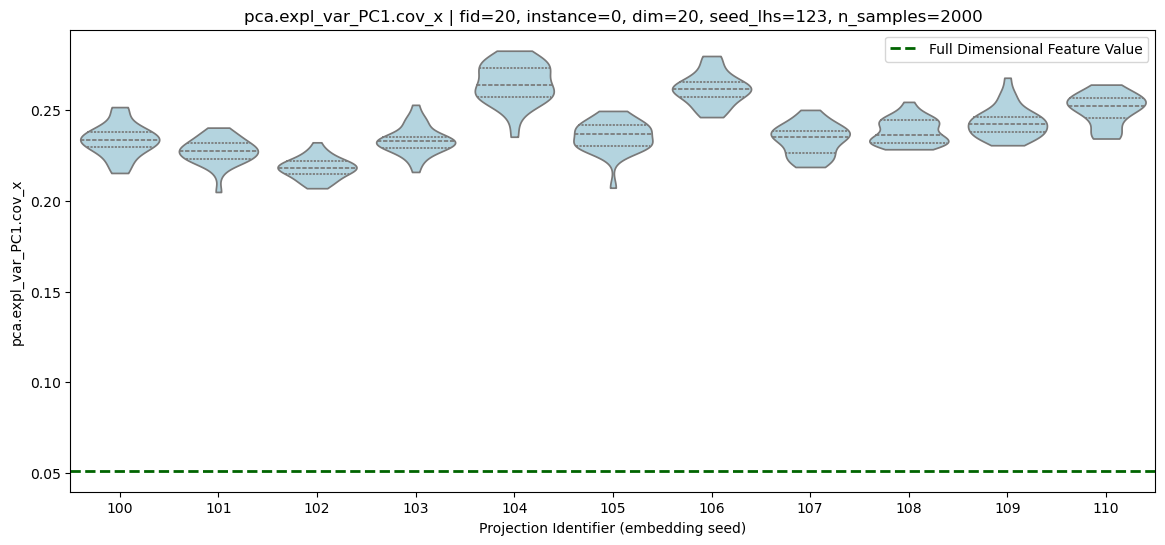

In [63]:
plot_feature_contrast_per_fid_instance_original_database(original_database=complete_data_cleaned,
                                                        reduced_database=reduced_data_cleaned,
                                                        feature_name='pca.expl_var_PC1.cov_x',
                                                        fid=20,
                                                        dataset_seed=123,
                                                        instance=0)

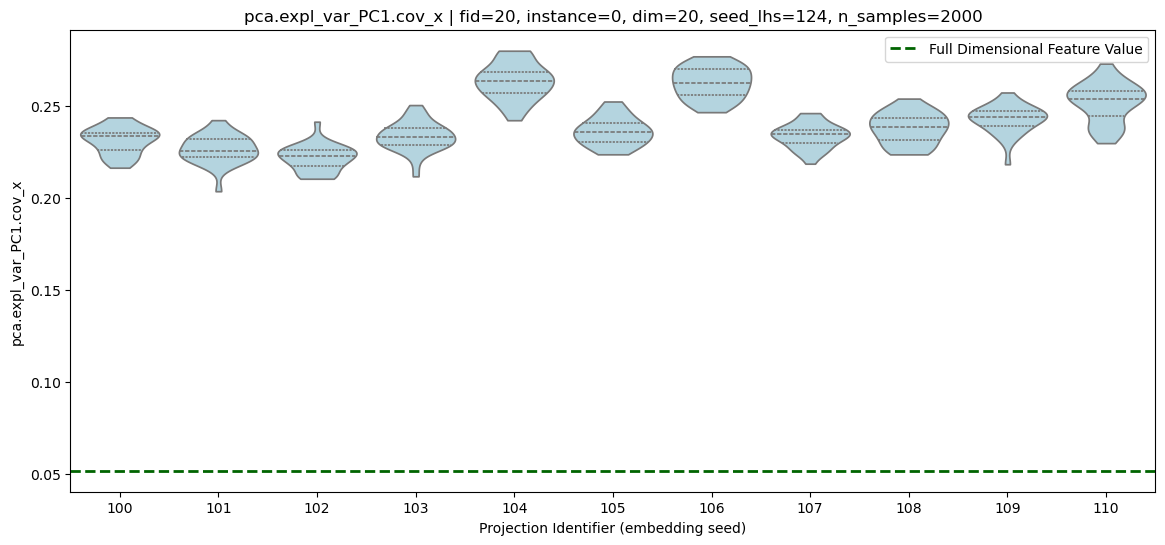

In [64]:
plot_feature_contrast_per_fid_instance_original_database(original_database=complete_data_cleaned,
                                                        reduced_database=reduced_data_cleaned,
                                                        feature_name='pca.expl_var_PC1.cov_x',
                                                        fid=20,
                                                        dataset_seed=124,
                                                        instance=0)

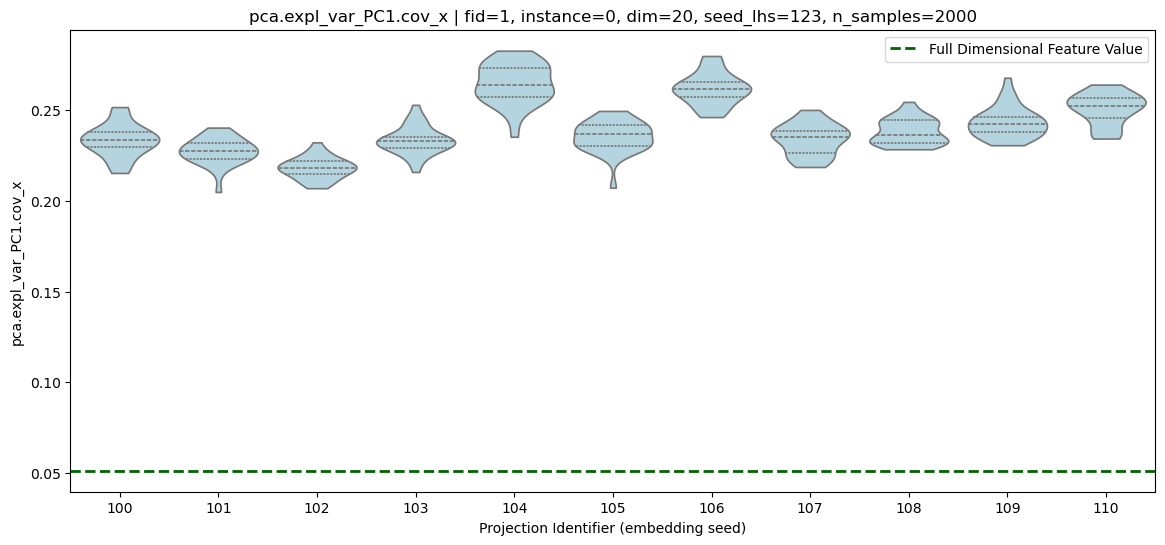

In [65]:
plot_feature_contrast_per_fid_instance_original_database(original_database=complete_data_cleaned,
                                                        reduced_database=reduced_data_cleaned,
                                                        feature_name='pca.expl_var_PC1.cov_x',
                                                        fid=1,
                                                        dataset_seed=123,
                                                        instance=0)

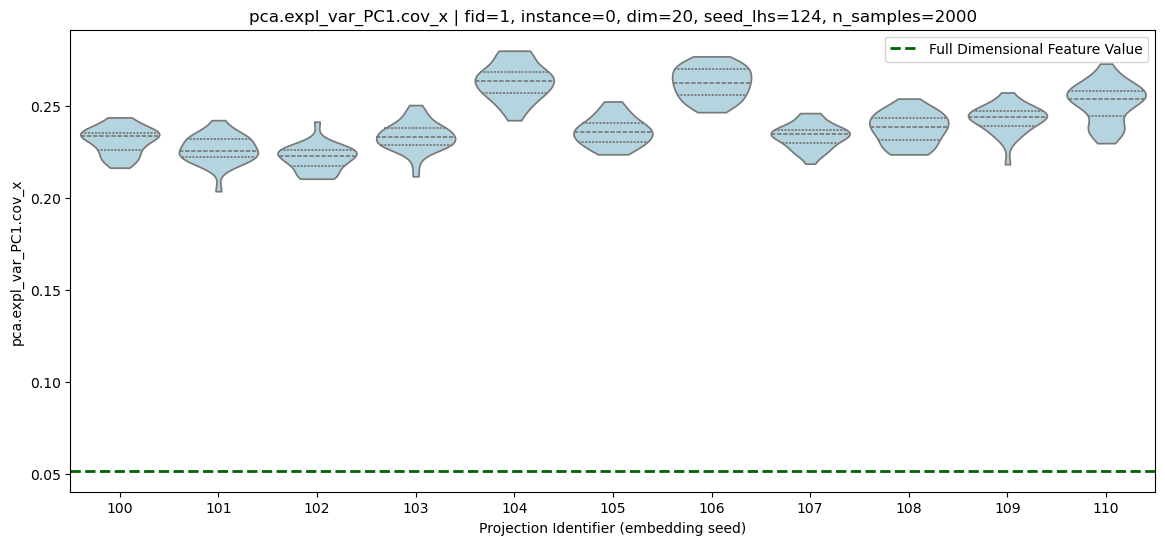

In [66]:
plot_feature_contrast_per_fid_instance_original_database(original_database=complete_data_cleaned,
                                                        reduced_database=reduced_data_cleaned,
                                                        feature_name='pca.expl_var_PC1.cov_x',
                                                        fid=1,
                                                        dataset_seed=124,
                                                        instance=0)

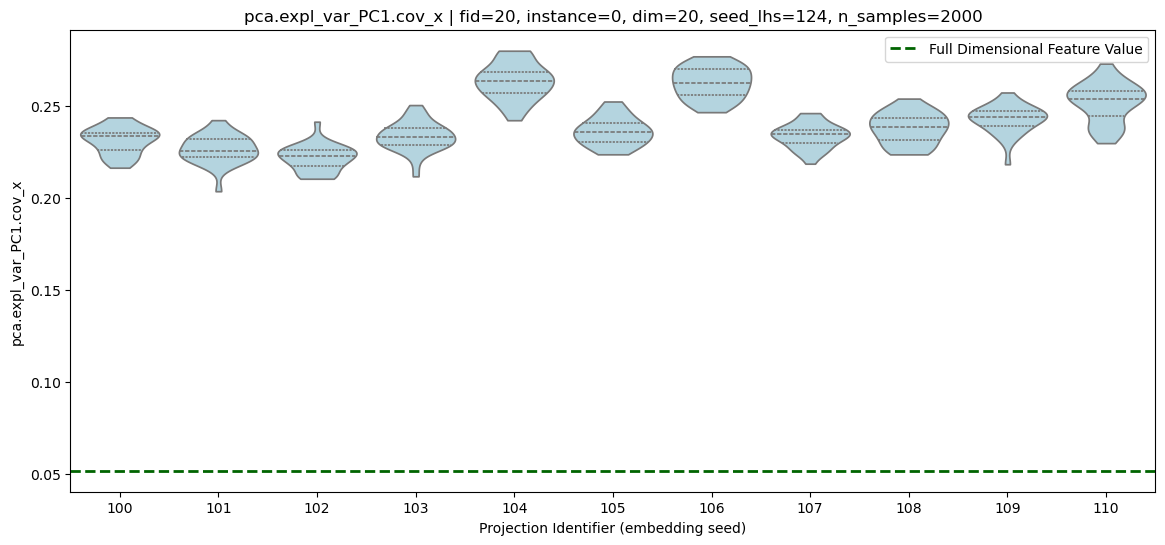

In [73]:
plot_feature_contrast_per_fid_instance_original_database(original_database=complete_data_cleaned,
                                                        reduced_database=reduced_data_cleaned,
                                                        feature_name='pca.expl_var_PC1.cov_x',
                                                        fid=20,
                                                        dataset_seed=124,
                                                        instance=0)